In [1]:
import copy
import json
import pickle
import sys
from collections import deque
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [ ]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only global-feature baseline
SUBTRACT_CONSTANT_GLOBAL_BASELINE = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings
VAL_FRAC = 0.4
SPLIT_SEED = 420

# Experiment settings
FEATURE_VARIANTS = {
    "LGR5_only": ["LGR5"],
    "AldoB_only": ["AldoB"],
}
FEATURE_VARIANT_LABELS = {
    "LGR5_only": "LGR5 only",
    "AldoB_only": "AldoB only",
}
DOMAIN_SIZE_BINS = [
    ("single", 1, 1),
    ("domain size 2-5", 2, 5),
    ("domain size 6-17", 6, 17),
    ("domain size 18+", 18, None),
]
DOMAIN_SIZE_ORDER = [name for name, _, _ in DOMAIN_SIZE_BINS]
DEPTH = 6
BASELINE_DEPTH = 0
CONSTANT_BASELINE_VALUE = 0.0
MAX_DISTANCE_HOPS = 10
MIN_DISTANCE_BIN_COUNT = 40
MIN_RECEPTIVE_FIELD_BIN_COUNT = 40

# Model settings
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Experiment output settings
EXPERIMENT_GROUP = "marker_domain_size_distance_comparison"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


In [3]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path


In [4]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [5]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.metadata import fill_missing_metadata_for_group
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(
        graphs,
        blacklist,
        print_summary=True,
    )
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

# graphs = graphs + g_spherical

print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

In [6]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


In [7]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_baseline_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
baseline_residual_transform = None
if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    if not USE_GLOBAL_FEATURES:
        raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
    baseline_residual_transform = global_baseline_transform
    target_transform = ChainedTargetTransform([
        baseline_residual_transform,
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - global-feature baseline"
else:
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)

if baseline_residual_transform is None:
    global_baseline_transform.fit(g_train)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)


Split -> train: 424 | val: 282
Training target: raw target
epoch 001 | train loss -0.0219 mae 0.1828 | val loss -0.0408 mae 0.1653
epoch 002 | train loss -0.0469 mae 0.1699 | val loss -0.0653 mae 0.1532
epoch 003 | train loss -0.0713 mae 0.1579 | val loss -0.0900 mae 0.1420
epoch 004 | train loss -0.0963 mae 0.1472 | val loss -0.1151 mae 0.1318
epoch 005 | train loss -0.1216 mae 0.1370 | val loss -0.1410 mae 0.1223
epoch 006 | train loss -0.1483 mae 0.1280 | val loss -0.1684 mae 0.1133
epoch 007 | train loss -0.1758 mae 0.1198 | val loss -0.1973 mae 0.1049
epoch 008 | train loss -0.2058 mae 0.1125 | val loss -0.2280 mae 0.0968
epoch 009 | train loss -0.2366 mae 0.1057 | val loss -0.2614 mae 0.0893
epoch 010 | train loss -0.2695 mae 0.0998 | val loss -0.2972 mae 0.0829
epoch 011 | train loss -0.3056 mae 0.0948 | val loss -0.3358 mae 0.0775
epoch 012 | train loss -0.3434 mae 0.0914 | val loss -0.3772 mae 0.0734
epoch 013 | train loss -0.3838 mae 0.0883 | val loss -0.4218 mae 0.0700
epoch

In [8]:
from src.data.preprocessing import remove_marker_features


def _resolve_marker_name(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)

    lower_lookup = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower_lookup:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower_lookup[key]


def build_feature_variant(graphs_in, keep_markers, marker_names_in):
    marker_names_in = list(marker_names_in)
    keep_indices = {_resolve_marker_name(name, marker_names_in) for name in keep_markers}
    remove_names = [name for i, name in enumerate(marker_names_in) if i not in keep_indices]
    graphs_out, marker_names_out = remove_marker_features(
        graphs_in,
        remove_names,
        marker_names=marker_names_in,
        inplace=False,
        return_marker_names=True,
    )
    return graphs_out, marker_names_out


def build_constant_feature_graphs(graphs_in, *, constant_value):
    graphs_out = [copy.deepcopy(g) for g in graphs_in]
    for g in graphs_out:
        n_nodes = int(g.x.shape[0])
        g.x = torch.full(
            (n_nodes, 1),
            float(constant_value),
            dtype=g.x.dtype,
            device=g.x.device,
        )
    return graphs_out, [f"constant_node_feature_{constant_value:g}"]


feature_data = {}
for variant_name, keep_markers in FEATURE_VARIANTS.items():
    train_variant, marker_names_variant = build_feature_variant(g_train, keep_markers, marker_names)
    val_variant, marker_names_val_variant = build_feature_variant(g_val, keep_markers, marker_names)

    if marker_names_variant != marker_names_val_variant:
        raise RuntimeError(f"Train/val marker mismatch for {variant_name}")

    feature_data[variant_name] = {
        "g_train": train_variant,
        "g_val": val_variant,
        "marker_names": marker_names_variant,
        "keep_markers": list(keep_markers),
    }
    print(f"{variant_name}: kept markers = {marker_names_variant}")

constant_train, constant_marker_names = build_constant_feature_graphs(
    g_train,
    constant_value=CONSTANT_BASELINE_VALUE,
)
constant_val, constant_marker_names_val = build_constant_feature_graphs(
    g_val,
    constant_value=CONSTANT_BASELINE_VALUE,
)
if constant_marker_names != constant_marker_names_val:
    raise RuntimeError("Train/val constant feature names do not match.")
constant_feature_data = {
    "g_train": constant_train,
    "g_val": constant_val,
    "marker_names": constant_marker_names,
}
print(f"constant baseline: node features = {constant_marker_names}")


LGR5_only: kept markers = ['LGR5']
AldoB_only: kept markers = ['AldoB']
constant baseline: node features = ['constant_node_feature_0']


In [9]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


In [10]:
trained_models = {}
center_baseline_models = {}
training_logs = {}
center_baseline_training_logs = {}

print()
print("=" * 80)
print(f"Training all-marker GINCurvature | depth={DEPTH}")
all_markers_model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(DEPTH),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
all_markers_model, all_markers_metrics, all_markers_history = train(
    all_markers_model,
    g_train,
    g_val,
    cfg,
)
all_markers_training_log = {
    "variant": "all_markers",
    "depth": int(DEPTH),
    "metrics": all_markers_metrics,
    "history": all_markers_history,
}

for variant_name, pack in feature_data.items():
    print()
    print("=" * 80)
    print(f"Training full GINCurvature | variant={variant_name} | depth={DEPTH}")

    model = GINCurvature(
        n_markers=int(pack["g_train"][0].x.size(1)),
        global_dim=infer_global_dim(pack["g_train"]),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(DEPTH),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )
    model, metrics, history = train(model, pack["g_train"], pack["g_val"], cfg)
    trained_models[variant_name] = model
    training_logs[variant_name] = {
        "variant": variant_name,
        "depth": int(DEPTH),
        "metrics": metrics,
        "history": history,
    }

    print(f"Training center-marker baseline | variant={variant_name} | depth={BASELINE_DEPTH}")
    baseline_model = GINCurvature(
        n_markers=int(pack["g_train"][0].x.size(1)),
        global_dim=infer_global_dim(pack["g_train"]),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(BASELINE_DEPTH),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )
    baseline_model, baseline_metrics, baseline_history = train(
        baseline_model,
        pack["g_train"],
        pack["g_val"],
        cfg,
    )
    center_baseline_models[variant_name] = baseline_model
    center_baseline_training_logs[variant_name] = {
        "variant": variant_name,
        "depth": int(BASELINE_DEPTH),
        "metrics": baseline_metrics,
        "history": baseline_history,
    }

print()
print("=" * 80)
print(f"Training constant baseline | depth={BASELINE_DEPTH} | value={CONSTANT_BASELINE_VALUE}")
constant_baseline_model = GINCurvature(
    n_markers=int(constant_feature_data["g_train"][0].x.size(1)),
    global_dim=infer_global_dim(constant_feature_data["g_train"]),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(BASELINE_DEPTH),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
constant_baseline_model, constant_baseline_metrics, constant_baseline_history = train(
    constant_baseline_model,
    constant_feature_data["g_train"],
    constant_feature_data["g_val"],
    cfg,
)
constant_baseline_training_log = {
    "variant": "constant_baseline",
    "constant_value": float(CONSTANT_BASELINE_VALUE),
    "depth": int(BASELINE_DEPTH),
    "metrics": constant_baseline_metrics,
    "history": constant_baseline_history,
}

print("Finished training.")



Training full GINCurvature | variant=LGR5_only | depth=8
epoch 001 | train loss 1.4091 mae 0.9463 | val loss 0.7612 mae 0.8165
epoch 002 | train loss 0.8175 mae 0.8596 | val loss 0.5859 mae 0.8297
epoch 003 | train loss 0.6995 mae 0.8186 | val loss 0.5403 mae 0.7737
epoch 004 | train loss 0.6244 mae 0.7919 | val loss 0.5370 mae 0.7773
epoch 005 | train loss 0.5794 mae 0.7710 | val loss 0.5466 mae 0.7892
epoch 006 | train loss 0.5479 mae 0.7607 | val loss 0.5677 mae 0.7847
epoch 007 | train loss 0.5290 mae 0.7515 | val loss 0.5786 mae 0.7891
epoch 008 | train loss 0.5204 mae 0.7486 | val loss 0.5612 mae 0.7734
epoch 009 | train loss 0.5051 mae 0.7417 | val loss 0.5126 mae 0.7525
epoch 010 | train loss 0.4952 mae 0.7375 | val loss 0.4789 mae 0.7472
epoch 011 | train loss 0.4874 mae 0.7331 | val loss 0.5717 mae 0.8335
epoch 012 | train loss 0.4853 mae 0.7327 | val loss 0.4870 mae 0.7520
epoch 013 | train loss 0.4780 mae 0.7263 | val loss 0.5736 mae 0.8373
epoch 014 | train loss 0.4761 ma

In [11]:
from src.inference.predict import predict_targets


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def _build_undirected_adjacency(edge_index, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    ei = edge_index.detach().cpu().numpy() if hasattr(edge_index, "detach") else np.asarray(edge_index)
    for u, v in zip(ei[0], ei[1]):
        u = int(u)
        v = int(v)
        if u == v:
            continue
        adjacency[u].append(v)
        adjacency[v].append(u)
    return [sorted(set(neigh)) for neigh in adjacency]


def _connected_components_from_mask(adjacency, mask):
    mask = np.asarray(mask, dtype=bool)
    seen = np.zeros(len(mask), dtype=bool)
    components = []
    for start in np.where(mask)[0]:
        start = int(start)
        if seen[start]:
            continue
        queue = deque([start])
        seen[start] = True
        comp = []
        while queue:
            node = queue.popleft()
            comp.append(node)
            for nbr in adjacency[node]:
                if mask[nbr] and not seen[nbr]:
                    seen[nbr] = True
                    queue.append(nbr)
        components.append(sorted(comp))
    return components


def domain_size_category(size):
    size = int(size)
    for label, lo, hi in DOMAIN_SIZE_BINS:
        if size >= lo and (hi is None or size <= hi):
            return label
    raise ValueError(f"No domain-size category for size={size}")


def assign_distance_to_nearest_marker_domain(graph, marker_name, marker_names_in):
    marker_idx = _resolve_marker_name(marker_name, marker_names_in)
    x = graph.x.detach().cpu().numpy() if hasattr(graph.x, "detach") else np.asarray(graph.x)
    source_mask = x[:, marker_idx] > 0.5
    n_nodes = int(x.shape[0])

    distances = np.full(n_nodes, np.nan, dtype=float)
    component_ids = np.full(n_nodes, -1, dtype=int)
    component_sizes = np.full(n_nodes, np.nan, dtype=float)
    categories = np.full(n_nodes, None, dtype=object)

    if not np.any(source_mask):
        return distances, component_ids, component_sizes, categories

    adjacency = _build_undirected_adjacency(graph.edge_index, n_nodes)
    components = _connected_components_from_mask(adjacency, source_mask)

    queue = deque()
    for comp_id, nodes in enumerate(components):
        size = len(nodes)
        category = domain_size_category(size)
        for node in nodes:
            distances[node] = 0.0
            component_ids[node] = comp_id
            component_sizes[node] = size
            categories[node] = category
            queue.append(node)

    while queue:
        node = queue.popleft()
        next_distance = distances[node] + 1.0
        if MAX_DISTANCE_HOPS is not None and next_distance > MAX_DISTANCE_HOPS:
            continue
        comp_id = component_ids[node]
        size = component_sizes[node]
        category = categories[node]
        for nbr in adjacency[node]:
            if np.isfinite(distances[nbr]):
                continue
            distances[nbr] = next_distance
            component_ids[nbr] = comp_id
            component_sizes[nbr] = size
            categories[nbr] = category
            queue.append(nbr)

    return distances, component_ids, component_sizes, categories


def count_positive_markers_in_receptive_field(graph, marker_name, marker_names_in, depth):
    marker_idx = _resolve_marker_name(marker_name, marker_names_in)
    x = graph.x.detach().cpu().numpy() if hasattr(graph.x, "detach") else np.asarray(graph.x)
    source_nodes = np.where(x[:, marker_idx] > 0.5)[0]
    counts = np.zeros(int(x.shape[0]), dtype=int)
    if len(source_nodes) == 0:
        return counts

    adjacency = _build_undirected_adjacency(graph.edge_index, int(x.shape[0]))
    max_depth = int(depth)
    for source in source_nodes:
        source = int(source)
        seen = {source}
        queue = deque([(source, 0)])
        while queue:
            node, distance = queue.popleft()
            counts[node] += 1
            if distance >= max_depth:
                continue
            for nbr in adjacency[node]:
                if nbr in seen:
                    continue
                seen.add(nbr)
                queue.append((nbr, distance + 1))
    return counts


def domain_distance_annotations_for_graphs(graphs_in, marker_name, marker_names_in):
    all_distances = []
    all_component_ids = []
    all_component_sizes = []
    all_categories = []
    all_rf_positive_marker_counts = []
    graph_indices = []
    local_node_indices = []

    for graph_index, graph in enumerate(graphs_in):
        distances, component_ids, component_sizes, categories = assign_distance_to_nearest_marker_domain(
            graph,
            marker_name,
            marker_names_in,
        )
        n_nodes = len(distances)
        rf_positive_marker_counts = count_positive_markers_in_receptive_field(
            graph,
            marker_name,
            marker_names_in,
            depth=DEPTH,
        )
        all_distances.append(distances)
        all_component_ids.append(component_ids)
        all_component_sizes.append(component_sizes)
        all_categories.append(categories)
        all_rf_positive_marker_counts.append(rf_positive_marker_counts)
        graph_indices.append(np.full(n_nodes, graph_index, dtype=int))
        local_node_indices.append(np.arange(n_nodes, dtype=int))

    return pd.DataFrame({
        "graph_index": np.concatenate(graph_indices),
        "local_node_index": np.concatenate(local_node_indices),
        "distance": np.concatenate(all_distances),
        "component_id": np.concatenate(all_component_ids),
        "component_size": np.concatenate(all_component_sizes),
        "domain_size_category": np.concatenate(all_categories),
        "rf_positive_marker_count": np.concatenate(all_rf_positive_marker_counts),
    })


def summarize_domain_distance_predictions(
    y_true,
    y_pred_full,
    log_var_full,
    y_pred_all_markers,
    log_var_all_markers,
    y_pred_center_baseline,
    y_pred_constant_baseline,
    y_pred_global_baseline,
    annotations,
    *,
    variant_name,
):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred_full = np.asarray(y_pred_full, dtype=float).reshape(-1)
    log_var_full = np.asarray(log_var_full, dtype=float).reshape(-1)
    y_pred_all_markers = np.asarray(y_pred_all_markers, dtype=float).reshape(-1)
    log_var_all_markers = np.asarray(log_var_all_markers, dtype=float).reshape(-1)
    y_pred_center_baseline = np.asarray(y_pred_center_baseline, dtype=float).reshape(-1)
    y_pred_constant_baseline = np.asarray(y_pred_constant_baseline, dtype=float).reshape(-1)
    y_pred_global_baseline = np.asarray(y_pred_global_baseline, dtype=float).reshape(-1)
    if not (len(y_true) == len(y_pred_full) == len(log_var_full) == len(y_pred_all_markers) == len(log_var_all_markers) == len(y_pred_center_baseline) == len(y_pred_constant_baseline) == len(y_pred_global_baseline) == len(annotations)):
        raise ValueError("Predictions and annotations must have matching lengths.")

    df = annotations.copy()
    df["variant"] = variant_name
    df["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    df["y_true"] = y_true
    df["y_true_global_residual"] = y_true - y_pred_global_baseline
    df["pred_var_full"] = np.exp(log_var_full)
    df["pred_var_all_markers"] = np.exp(log_var_all_markers)
    df["sqerr_full"] = (y_pred_full - y_true) ** 2
    df["sqerr_all_markers"] = (y_pred_all_markers - y_true) ** 2
    df["sqerr_center_baseline"] = (y_pred_center_baseline - y_true) ** 2
    df["sqerr_constant_baseline"] = (y_pred_constant_baseline - y_true) ** 2
    df["delta_sqerr_center_baseline"] = df["sqerr_full"] - df["sqerr_center_baseline"]
    df["delta_sqerr_all_markers_center_baseline"] = df["sqerr_all_markers"] - df["sqerr_center_baseline"]
    df["delta_sqerr_constant_baseline"] = df["sqerr_full"] - df["sqerr_constant_baseline"]

    finite = (
        np.isfinite(df["distance"].to_numpy(dtype=float))
        & df["domain_size_category"].notna().to_numpy()
        & np.isfinite(df["y_true"].to_numpy(dtype=float))
        & np.isfinite(df["pred_var_full"].to_numpy(dtype=float))
        & np.isfinite(df["pred_var_all_markers"].to_numpy(dtype=float))
    )
    if MAX_DISTANCE_HOPS is not None:
        finite &= df["distance"].to_numpy(dtype=float) <= MAX_DISTANCE_HOPS
    df = df.loc[finite].copy()
    df["distance"] = df["distance"].astype(int)

    rows = []
    for (category, distance), sub in df.groupby(["domain_size_category", "distance"], sort=False):
        n = len(sub)
        if n < MIN_DISTANCE_BIN_COUNT:
            continue
        row = {
            "variant": variant_name,
            "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
            "domain_size_category": category,
            "distance": int(distance),
            "n_nodes": int(n),
            "true_mean": float(sub["y_true"].mean()),
            "true_var": float(sub["y_true"].var(ddof=1)) if n > 1 else 0.0,
            "true_global_residual_mean": float(sub["y_true_global_residual"].mean()),
            "true_global_residual_var": float(sub["y_true_global_residual"].var(ddof=1)) if n > 1 else 0.0,
            "pred_var_full_mean": float(sub["pred_var_full"].mean()),
            "sem_pred_var_full": float(sub["pred_var_full"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "pred_var_all_markers_mean": float(sub["pred_var_all_markers"].mean()),
            "sem_pred_var_all_markers": float(sub["pred_var_all_markers"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        }
        for key in ["full", "all_markers", "center_baseline", "constant_baseline"]:
            col = f"sqerr_{key}"
            row[f"mse_{key}"] = float(sub[col].mean())
            row[f"sem_mse_{key}"] = float(sub[col].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
        for key in ["center_baseline", "constant_baseline"]:
            col = f"delta_sqerr_{key}"
            row[f"delta_mse_{key}"] = float(sub[col].mean())
            row[f"sem_delta_mse_{key}"] = float(sub[col].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
        col = "delta_sqerr_all_markers_center_baseline"
        row["delta_mse_all_markers_center_baseline"] = float(sub[col].mean())
        row["sem_delta_mse_all_markers_center_baseline"] = float(sub[col].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
        rows.append(row)

    summary = pd.DataFrame(rows)
    if len(summary):
        summary["domain_size_category"] = pd.Categorical(
            summary["domain_size_category"],
            categories=DOMAIN_SIZE_ORDER,
            ordered=True,
        )
        summary = summary.sort_values(["variant", "domain_size_category", "distance"]).reset_index(drop=True)
    return df, summary


def summarize_receptive_field_count_predictions(
    y_true,
    y_pred_full,
    log_var_full,
    y_pred_all_markers,
    log_var_all_markers,
    annotations,
    *,
    variant_name,
):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred_full = np.asarray(y_pred_full, dtype=float).reshape(-1)
    log_var_full = np.asarray(log_var_full, dtype=float).reshape(-1)
    y_pred_all_markers = np.asarray(y_pred_all_markers, dtype=float).reshape(-1)
    log_var_all_markers = np.asarray(log_var_all_markers, dtype=float).reshape(-1)
    if not (len(y_true) == len(y_pred_full) == len(log_var_full) == len(y_pred_all_markers) == len(log_var_all_markers) == len(annotations)):
        raise ValueError("Predictions and annotations must have matching lengths.")

    df = annotations.copy()
    df["variant"] = variant_name
    df["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    df["y_true"] = y_true
    df["y_pred_full"] = y_pred_full
    df["y_pred_all_markers"] = y_pred_all_markers
    df["sqerr_full"] = (y_pred_full - y_true) ** 2
    df["sqerr_all_markers"] = (y_pred_all_markers - y_true) ** 2
    df["pred_var_full"] = np.exp(log_var_full)
    df["pred_var_all_markers"] = np.exp(log_var_all_markers)
    finite = (
        np.isfinite(df["rf_positive_marker_count"].to_numpy(dtype=float))
        & np.isfinite(df["sqerr_full"].to_numpy(dtype=float))
        & np.isfinite(df["sqerr_all_markers"].to_numpy(dtype=float))
        & np.isfinite(df["pred_var_full"].to_numpy(dtype=float))
        & np.isfinite(df["pred_var_all_markers"].to_numpy(dtype=float))
    )
    df = df.loc[finite].copy()
    df["rf_positive_marker_count"] = df["rf_positive_marker_count"].astype(int)

    rows = []
    for rf_count, sub in df.groupby("rf_positive_marker_count", sort=True):
        n = len(sub)
        if n < MIN_RECEPTIVE_FIELD_BIN_COUNT:
            continue
        rows.append({
            "variant": variant_name,
            "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
            "rf_positive_marker_count": int(rf_count),
            "n_nodes": int(n),
            "mse_full": float(sub["sqerr_full"].mean()),
            "sem_mse_full": float(sub["sqerr_full"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "mse_all_markers": float(sub["sqerr_all_markers"].mean()),
            "sem_mse_all_markers": float(sub["sqerr_all_markers"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "pred_var_full_mean": float(sub["pred_var_full"].mean()),
            "sem_pred_var_full": float(sub["pred_var_full"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "pred_var_all_markers_mean": float(sub["pred_var_all_markers"].mean()),
            "sem_pred_var_all_markers": float(sub["pred_var_all_markers"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "pred_mean_full": float(sub["y_pred_full"].mean()),
            "sem_pred_mean_full": float(sub["y_pred_full"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "pred_mean_all_markers": float(sub["y_pred_all_markers"].mean()),
            "sem_pred_mean_all_markers": float(sub["y_pred_all_markers"].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        })
    summary = pd.DataFrame(rows)
    if len(summary):
        summary = summary.sort_values("rf_positive_marker_count").reset_index(drop=True)
    return df, summary


In [12]:
def predict_model_on_graphs(graphs_in, model):
    y_true, y_pred, log_var, _ = predict_targets(
        graphs_in,
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    return {
        "y_true": select_target_column(y_true, TARGET_INDEX_FOR_PLOTS),
        "y_pred": select_target_column(y_pred, TARGET_INDEX_FOR_PLOTS),
        "log_var": select_target_column(log_var, TARGET_INDEX_FOR_PLOTS),
    }


constant_predictions = predict_model_on_graphs(
    constant_feature_data["g_val"],
    constant_baseline_model,
)
all_markers_predictions = predict_model_on_graphs(
    g_val,
    all_markers_model,
)
global_baseline_predictions = select_target_column(
    global_baseline_transform._predict_baseline(g_val),
    TARGET_INDEX_FOR_PLOTS,
)

node_tables = {}
summary_tables = {}
rf_count_node_tables = {}
rf_count_summary_tables = {}
predictions_by_variant = {}

for variant_name, pack in feature_data.items():
    marker_name = pack["keep_markers"][0]
    full_pred = predict_model_on_graphs(pack["g_val"], trained_models[variant_name])
    center_pred = predict_model_on_graphs(pack["g_val"], center_baseline_models[variant_name])

    if not np.allclose(full_pred["y_true"], center_pred["y_true"], equal_nan=True):
        raise RuntimeError(f"Center baseline truth differs for {variant_name}.")
    if not np.allclose(full_pred["y_true"], constant_predictions["y_true"], equal_nan=True):
        raise RuntimeError(f"Constant baseline truth differs for {variant_name}.")
    if not np.allclose(full_pred["y_true"], all_markers_predictions["y_true"], equal_nan=True):
        raise RuntimeError(f"All-marker model truth differs for {variant_name}.")

    annotations = domain_distance_annotations_for_graphs(
        g_val,
        marker_name,
        marker_names,
    )
    node_df, summary_df = summarize_domain_distance_predictions(
        full_pred["y_true"],
        full_pred["y_pred"],
        full_pred["log_var"],
        all_markers_predictions["y_pred"],
        all_markers_predictions["log_var"],
        center_pred["y_pred"],
        constant_predictions["y_pred"],
        global_baseline_predictions,
        annotations,
        variant_name=variant_name,
    )
    rf_count_node_df, rf_count_summary_df = summarize_receptive_field_count_predictions(
        full_pred["y_true"],
        full_pred["y_pred"],
        full_pred["log_var"],
        all_markers_predictions["y_pred"],
        all_markers_predictions["log_var"],
        annotations,
        variant_name=variant_name,
    )

    predictions_by_variant[variant_name] = {
        "full": full_pred,
        "all_markers": all_markers_predictions,
        "center_baseline": center_pred,
    }
    node_tables[variant_name] = node_df
    summary_tables[variant_name] = summary_df
    rf_count_node_tables[variant_name] = rf_count_node_df
    rf_count_summary_tables[variant_name] = rf_count_summary_df
    print(
        f"{variant_name}: {len(node_df)} annotated nodes, "
        f"{len(summary_df)} plotted distance/category bins, "
        f"{len(rf_count_summary_df)} plotted receptive-field-count bins."
    )

summary_all = pd.concat(summary_tables.values(), ignore_index=True) if summary_tables else pd.DataFrame()
rf_count_summary_all = pd.concat(rf_count_summary_tables.values(), ignore_index=True) if rf_count_summary_tables else pd.DataFrame()
summary_all.head()


LGR5_only: 123949 annotated nodes, 52 plotted distance/category bins, 197 plotted receptive-field-count bins.
AldoB_only: 122490 annotated nodes, 52 plotted distance/category bins, 272 plotted receptive-field-count bins.


,variant,variant_label,domain_size_category,distance,n_nodes,true_mean,true_var,true_global_residual_mean,true_global_residual_var,pred_var_full_mean,...,mse_full,sem_mse_full,mse_center_baseline,sem_mse_center_baseline,mse_constant_baseline,sem_mse_constant_baseline,delta_mse_center_baseline,sem_delta_mse_center_baseline,delta_mse_constant_baseline,sem_delta_mse_constant_baseline
0,LGR5_only,LGR5 only,single,0,356,0.049186,0.006026,0.013507,0.005729,0.002677,...,0.004985,0.000611,0.005603,0.000724,0.005933,0.000682,-0.000618,0.000237,-0.000948,0.000232
1,LGR5_only,LGR5 only,single,1,1467,0.046577,0.006342,0.009736,0.005925,0.002597,...,0.005049,0.000318,0.006170,0.000367,0.006081,0.000368,-0.001122,0.000124,-0.001033,0.000118
2,LGR5_only,LGR5 only,single,2,1905,0.035066,0.006082,-0.002563,0.005533,0.002452,...,0.004758,0.000255,0.005588,0.000300,0.005607,0.000304,-0.000830,0.000098,-0.000849,0.000097
3,LGR5_only,LGR5 only,single,3,2051,0.022995,0.005472,-0.013806,0.004919,0.002235,...,0.004311,0.000204,0.005033,0.000246,0.005148,0.000254,-0.000722,0.000077,-0.000837,0.000083
4,LGR5_only,LGR5 only,single,4,2120,0.018669,0.005251,-0.018328,0.004486,0.001917,...,0.004080,0.000221,0.004722,0.000269,0.004889,0.000279,-0.000641,0.000069,-0.000809,0.000078


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/curvature_mean_variance_by_domain_size_and_distance.pdf


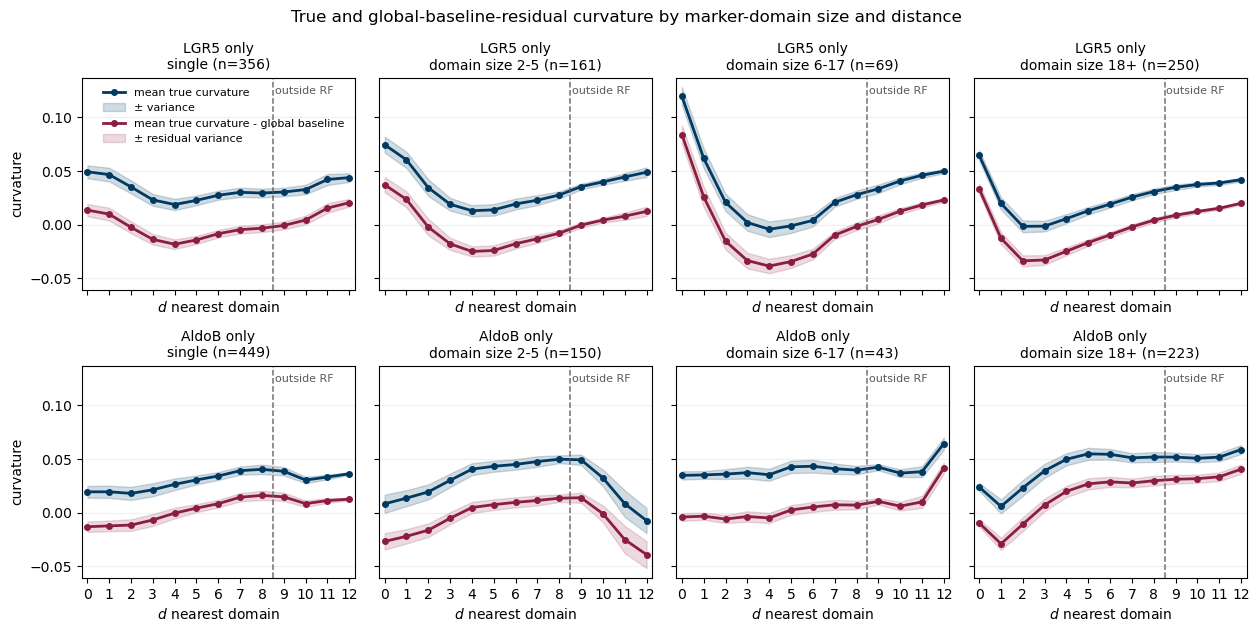

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/mse_by_domain_size_and_distance.pdf


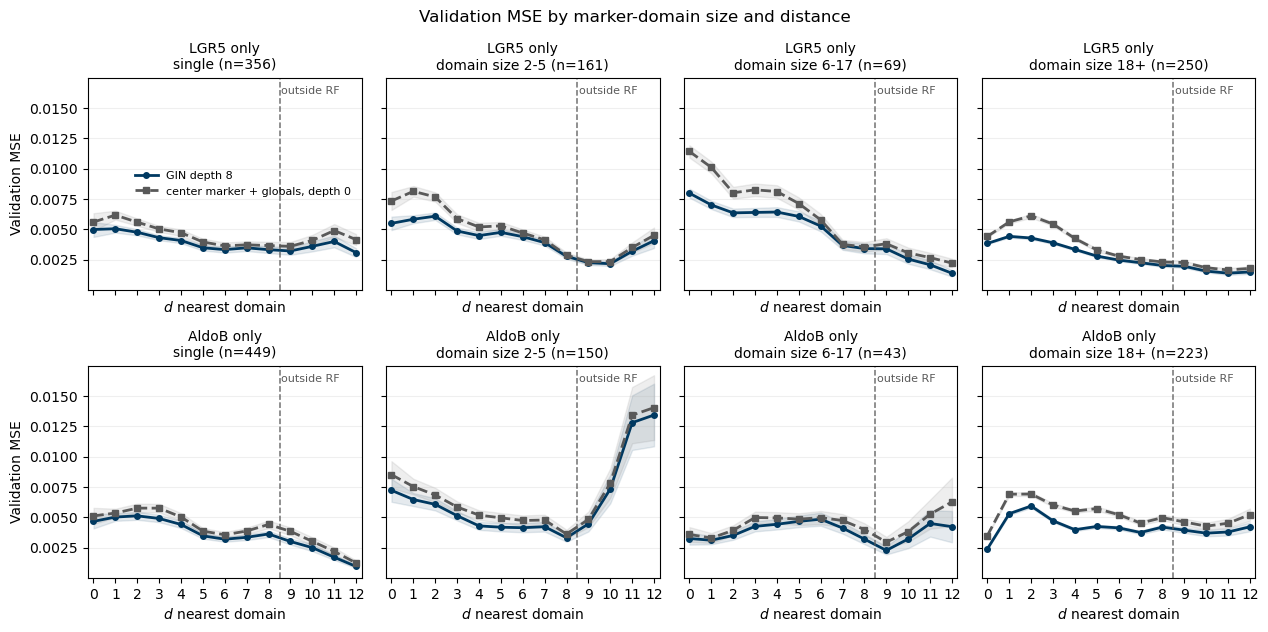

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/delta_mse_by_domain_size_and_distance.pdf


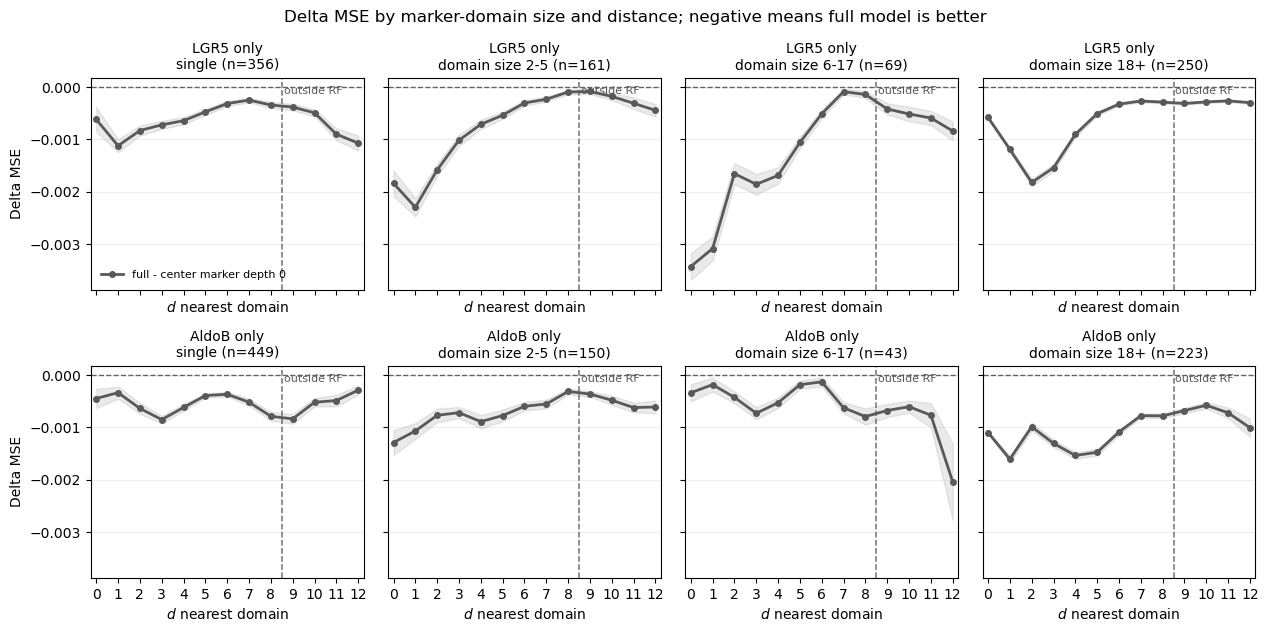

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/predicted_variance_by_domain_size_and_distance.pdf


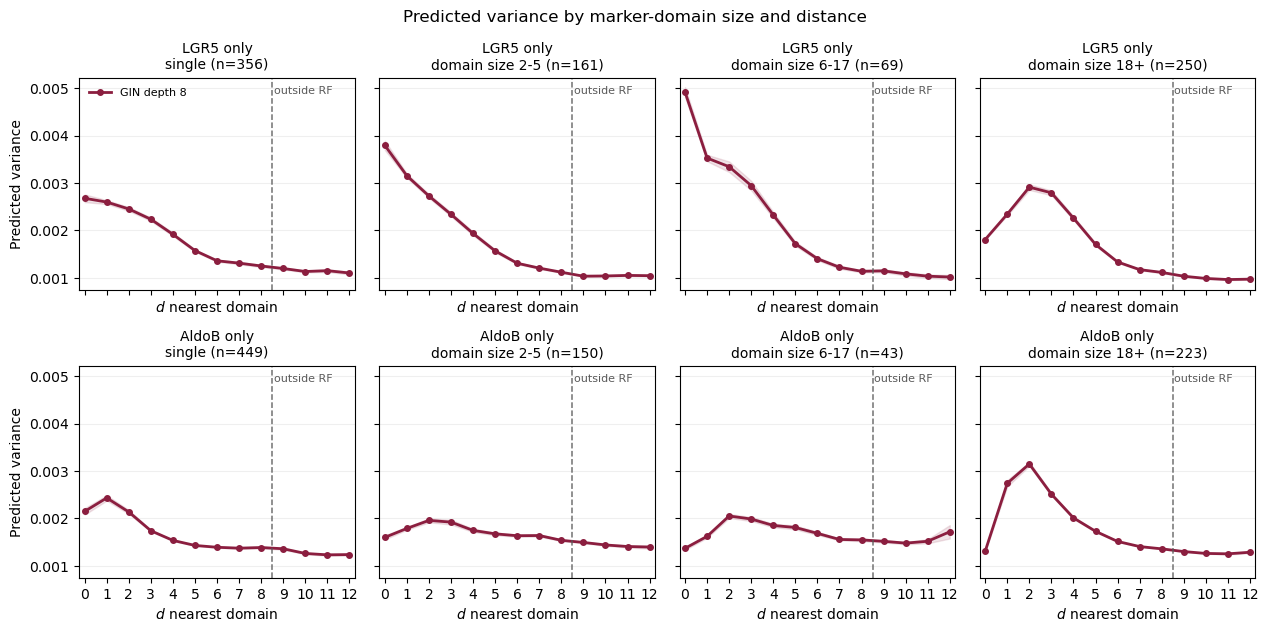

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/mse_by_receptive_field_positive_marker_count.pdf


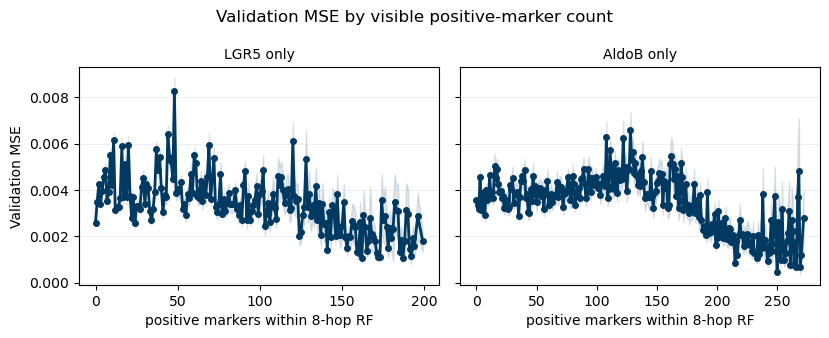

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839/figures/predicted_variance_by_receptive_field_positive_marker_count.pdf


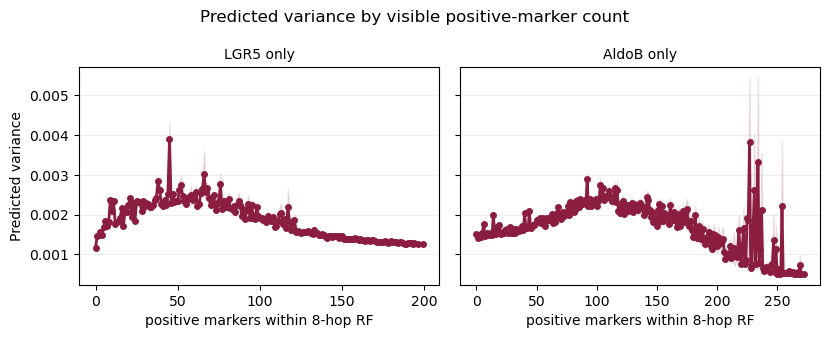

In [13]:
def _panel_grid():
    n_rows = len(FEATURE_VARIANTS)
    n_cols = len(DOMAIN_SIZE_ORDER)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.2 * n_cols, 3.2 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    return fig, axes


def _domain_count(variant_name, category):
    if variant_name not in node_tables:
        return 0
    table = node_tables[variant_name]
    if len(table) == 0:
        return 0
    mask = (
        table["domain_size_category"].astype(str).eq(str(category))
        & (table["component_id"].to_numpy(dtype=int) >= 0)
    )
    if not np.any(mask):
        return 0
    domains = table.loc[mask, ["graph_index", "component_id"]].drop_duplicates()
    return int(len(domains))


def _draw_receptive_field_boundary(ax):
    boundary = int(DEPTH) + 0.5
    if boundary > MAX_DISTANCE_HOPS + 0.25:
        return
    ax.axvline(boundary, color="0.35", linestyle="--", linewidth=1.1, alpha=0.85)
    ax.text(
        boundary + 0.08,
        0.96,
        "outside RF",
        transform=ax.get_xaxis_transform(),
        ha="left",
        va="top",
        fontsize=8,
        color="0.35",
    )


def _format_domain_panel(ax, variant_name, category, *, ylabel=None):
    variant_label = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    n_domains = _domain_count(variant_name, category)
    ax.set_title(f"{variant_label}\n{category} (n={n_domains})", fontsize=10)
    ax.set_xlabel(r"$d$ nearest domain")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_xlim(-0.25, MAX_DISTANCE_HOPS + 0.25)
    ax.set_xticks(np.arange(0, MAX_DISTANCE_HOPS + 1, dtype=int))
    _draw_receptive_field_boundary(ax)
    ax.grid(True, axis="y", alpha=0.2)


def _subset_summary(variant_name, category):
    if variant_name not in summary_tables:
        return pd.DataFrame()
    table = summary_tables[variant_name]
    if len(table) == 0:
        return table
    return table.loc[table["domain_size_category"].astype(str) == str(category)].sort_values("distance")


def plot_curvature_mean_variance():
    fig, axes = _panel_grid()
    for row_i, variant_name in enumerate(FEATURE_VARIANTS):
        for col_i, category in enumerate(DOMAIN_SIZE_ORDER):
            ax = axes[row_i, col_i]
            table = _subset_summary(variant_name, category)
            if len(table) == 0:
                ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
                _format_domain_panel(ax, variant_name, category, ylabel="curvature" if col_i == 0 else None)
                continue

            x = table["distance"].to_numpy(dtype=float)
            mean = table["true_mean"].to_numpy(dtype=float)
            var = np.maximum(table["true_var"].to_numpy(dtype=float), 0.0)
            residual_mean = table["true_global_residual_mean"].to_numpy(dtype=float)
            residual_var = np.maximum(table["true_global_residual_var"].to_numpy(dtype=float), 0.0)

            ax.plot(
                x,
                mean,
                "-o",
                color="#003961",
                linewidth=2,
                markersize=4,
                label="mean true curvature",
            )
            ax.fill_between(
                x,
                mean - var,
                mean + var,
                color="#003961",
                alpha=0.18,
                label="± variance",
            )
            ax.plot(
                x,
                residual_mean,
                "-o",
                color="#8b1e3f",
                linewidth=2,
                markersize=4,
                label="mean true curvature - global baseline",
            )
            ax.fill_between(
                x,
                residual_mean - residual_var,
                residual_mean + residual_var,
                color="#8b1e3f",
                alpha=0.16,
                label="± residual variance",
            )
            _format_domain_panel(ax, variant_name, category, ylabel="curvature" if col_i == 0 else None)
            if row_i == 0 and col_i == 0:
                ax.legend(frameon=False, fontsize=8, loc="best")
    fig.suptitle("True and global-baseline-residual curvature by marker-domain size and distance")
    plt.tight_layout()
    save_mpl_figure(fig, "curvature_mean_variance_by_domain_size_and_distance")
    plt.show()
    return fig, axes


def plot_mse_by_domain_distance():
    fig, axes = _panel_grid()
    model_specs = [
        ("mse_full", "sem_mse_full", f"marker subset, depth {DEPTH}", "#003961", "-o"),
        ("mse_all_markers", "sem_mse_all_markers", f"all markers, depth {DEPTH}", "#8b1e3f", "-^"),
        ("mse_center_baseline", "sem_mse_center_baseline", f"center marker + globals, depth {BASELINE_DEPTH}", "0.35", "--s"),
    ]
    for row_i, variant_name in enumerate(FEATURE_VARIANTS):
        for col_i, category in enumerate(DOMAIN_SIZE_ORDER):
            ax = axes[row_i, col_i]
            table = _subset_summary(variant_name, category)
            if len(table) == 0:
                ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
                _format_domain_panel(ax, variant_name, category, ylabel="MSE" if col_i == 0 else None)
                continue
            for mse_col, sem_col, label, color, style in model_specs:
                ax.plot(
                    table["distance"],
                    table[mse_col],
                    style,
                    color=color,
                    linewidth=2,
                    markersize=4,
                    label=label,
                )
                ax.fill_between(
                    table["distance"].to_numpy(),
                    (table[mse_col] - table[sem_col]).to_numpy(),
                    (table[mse_col] + table[sem_col]).to_numpy(),
                    color=color,
                    alpha=0.10,
                )
            _format_domain_panel(ax, variant_name, category, ylabel="Validation MSE" if col_i == 0 else None)
            if row_i == 0 and col_i == 0:
                ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Validation MSE by marker-domain size and distance")
    plt.tight_layout()
    save_mpl_figure(fig, "mse_by_domain_size_and_distance")
    plt.show()
    return fig, axes


def plot_delta_mse_by_domain_distance():
    fig, axes = _panel_grid()
    delta_specs = [
        ("delta_mse_center_baseline", "sem_delta_mse_center_baseline", f"subset - center marker depth {BASELINE_DEPTH}", "#003961", "-o"),
        ("delta_mse_all_markers_center_baseline", "sem_delta_mse_all_markers_center_baseline", f"all markers - center marker depth {BASELINE_DEPTH}", "#8b1e3f", "-^"),
    ]
    for row_i, variant_name in enumerate(FEATURE_VARIANTS):
        for col_i, category in enumerate(DOMAIN_SIZE_ORDER):
            ax = axes[row_i, col_i]
            table = _subset_summary(variant_name, category)
            if len(table) == 0:
                ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
                _format_domain_panel(ax, variant_name, category, ylabel="Delta MSE" if col_i == 0 else None)
                continue
            for delta_col, sem_col, label, color, style in delta_specs:
                ax.plot(
                    table["distance"],
                    table[delta_col],
                    style,
                    color=color,
                    linewidth=2,
                    markersize=4,
                    label=label,
                )
                ax.fill_between(
                    table["distance"].to_numpy(),
                    (table[delta_col] - table[sem_col]).to_numpy(),
                    (table[delta_col] + table[sem_col]).to_numpy(),
                    color=color,
                    alpha=0.12,
                )
            ax.axhline(0, color="0.25", linestyle="--", linewidth=1.0, alpha=0.8)
            _format_domain_panel(ax, variant_name, category, ylabel="Delta MSE" if col_i == 0 else None)
            if row_i == 0 and col_i == 0:
                ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Delta MSE by marker-domain size and distance; negative means model beats center baseline")
    plt.tight_layout()
    save_mpl_figure(fig, "delta_mse_by_domain_size_and_distance")
    plt.show()
    return fig, axes


def plot_predicted_variance_by_domain_distance():
    fig, axes = _panel_grid()
    variance_specs = [
        ("pred_var_full_mean", "sem_pred_var_full", f"marker subset, depth {DEPTH}", "#003961", "-o"),
        ("pred_var_all_markers_mean", "sem_pred_var_all_markers", f"all markers, depth {DEPTH}", "#8b1e3f", "-^"),
    ]
    for row_i, variant_name in enumerate(FEATURE_VARIANTS):
        for col_i, category in enumerate(DOMAIN_SIZE_ORDER):
            ax = axes[row_i, col_i]
            table = _subset_summary(variant_name, category)
            if len(table) == 0:
                ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
                _format_domain_panel(ax, variant_name, category, ylabel="Predicted variance" if col_i == 0 else None)
                continue
            for mean_col, sem_col, label, color, style in variance_specs:
                ax.plot(
                    table["distance"],
                    table[mean_col],
                    style,
                    color=color,
                    linewidth=2,
                    markersize=4,
                    label=label,
                )
                ax.fill_between(
                    table["distance"].to_numpy(),
                    np.maximum((table[mean_col] - table[sem_col]).to_numpy(), 0.0),
                    (table[mean_col] + table[sem_col]).to_numpy(),
                    color=color,
                    alpha=0.12,
                )
            _format_domain_panel(ax, variant_name, category, ylabel="Predicted variance" if col_i == 0 else None)
            if row_i == 0 and col_i == 0:
                ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Predicted variance by marker-domain size and distance")
    plt.tight_layout()
    save_mpl_figure(fig, "predicted_variance_by_domain_size_and_distance")
    plt.show()
    return fig, axes


def _rf_count_panel_grid():
    fig, axes = plt.subplots(
        1,
        len(FEATURE_VARIANTS),
        figsize=(4.2 * len(FEATURE_VARIANTS), 3.4),
        sharey=True,
        squeeze=False,
    )
    return fig, axes[0]


def _subset_rf_count_summary(variant_name):
    if variant_name not in rf_count_summary_tables:
        return pd.DataFrame()
    return rf_count_summary_tables[variant_name].sort_values("rf_positive_marker_count")


def _format_rf_count_panel(ax, variant_name, *, ylabel=None):
    ax.set_title(FEATURE_VARIANT_LABELS.get(variant_name, variant_name), fontsize=10)
    ax.set_xlabel(f"positive markers within {DEPTH}-hop RF")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.2)


def _running_average_curve(x, y, *, window=3, n_points=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) == 0:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    smooth = pd.Series(y).rolling(
        window=int(window),
        center=True,
        min_periods=1,
    ).mean().to_numpy()

    unique_x, unique_idx = np.unique(x, return_index=True)
    smooth = smooth[unique_idx]
    if len(unique_x) < 2:
        return unique_x, smooth

    x_dense = np.linspace(unique_x.min(), unique_x.max(), min(int(n_points), max(2, 12 * len(unique_x))))
    y_dense = np.interp(x_dense, unique_x, smooth)
    return x_dense, y_dense


def _plot_metric_with_running_average(
    ax,
    table,
    *,
    mean_col,
    sem_col,
    label,
    color,
    marker,
    lower_bound=None,
):
    x = table["rf_positive_marker_count"].to_numpy(dtype=float)
    y = table[mean_col].to_numpy(dtype=float)
    sem = table[sem_col].to_numpy(dtype=float)
    lower = y - sem
    upper = y + sem
    if lower_bound is not None:
        lower = np.maximum(lower, float(lower_bound))

    ax.plot(
        x,
        y,
        linestyle="none",
        marker=marker,
        color=color,
        markersize=4,
        alpha=0.48,
        label=f"{label} bins",
    )
    ax.fill_between(x, lower, upper, color=color, alpha=0.07)

    x_smooth, y_smooth = _running_average_curve(x, y, window=3)
    ax.plot(
        x_smooth,
        y_smooth,
        "-",
        color=color,
        linewidth=2.2,
        alpha=0.85,
        label=f"{label} running avg",
    )


def plot_mse_by_receptive_field_marker_count():
    fig, axes = _rf_count_panel_grid()
    mse_specs = [
        ("mse_full", "sem_mse_full", f"marker subset, depth {DEPTH}", "#4f6f88", "o"),
        ("mse_all_markers", "sem_mse_all_markers", f"all markers, depth {DEPTH}", "#a05a70", "^"),
    ]
    for ax_i, (ax, variant_name) in enumerate(zip(axes, FEATURE_VARIANTS)):
        table = _subset_rf_count_summary(variant_name)
        if len(table) == 0:
            ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
            _format_rf_count_panel(ax, variant_name, ylabel="Validation MSE" if ax_i == 0 else None)
            continue
        for mean_col, sem_col, label, color, marker in mse_specs:
            _plot_metric_with_running_average(
                ax,
                table,
                mean_col=mean_col,
                sem_col=sem_col,
                label=label,
                color=color,
                marker=marker,
            )
        _format_rf_count_panel(ax, variant_name, ylabel="Validation MSE" if ax_i == 0 else None)
        if ax_i == 0:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle("Validation MSE by visible positive-marker count")
    plt.tight_layout()
    save_mpl_figure(fig, "mse_by_receptive_field_positive_marker_count")
    plt.show()
    return fig, axes


def plot_predicted_variance_by_receptive_field_marker_count():
    fig, axes = _rf_count_panel_grid()
    variance_specs = [
        ("pred_var_full_mean", "sem_pred_var_full", f"marker subset, depth {DEPTH}", "#4f6f88", "o"),
        ("pred_var_all_markers_mean", "sem_pred_var_all_markers", f"all markers, depth {DEPTH}", "#a05a70", "^"),
    ]
    for ax_i, (ax, variant_name) in enumerate(zip(axes, FEATURE_VARIANTS)):
        table = _subset_rf_count_summary(variant_name)
        if len(table) == 0:
            ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
            _format_rf_count_panel(ax, variant_name, ylabel="Predicted variance" if ax_i == 0 else None)
            continue
        for mean_col, sem_col, label, color, marker in variance_specs:
            _plot_metric_with_running_average(
                ax,
                table,
                mean_col=mean_col,
                sem_col=sem_col,
                label=label,
                color=color,
                marker=marker,
                lower_bound=0.0,
            )
        _format_rf_count_panel(ax, variant_name, ylabel="Predicted variance" if ax_i == 0 else None)
        if ax_i == 0:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle("Predicted variance by visible positive-marker count")
    plt.tight_layout()
    save_mpl_figure(fig, "predicted_variance_by_receptive_field_positive_marker_count")
    plt.show()
    return fig, axes


def plot_predicted_curvature_by_receptive_field_marker_count():
    fig, axes = _rf_count_panel_grid()
    prediction_specs = [
        ("pred_mean_full", "sem_pred_mean_full", f"marker subset, depth {DEPTH}", "#4f6f88", "o"),
        ("pred_mean_all_markers", "sem_pred_mean_all_markers", f"all markers, depth {DEPTH}", "#a05a70", "^"),
    ]
    for ax_i, (ax, variant_name) in enumerate(zip(axes, FEATURE_VARIANTS)):
        table = _subset_rf_count_summary(variant_name)
        if len(table) == 0:
            ax.text(0.5, 0.5, "no bins", transform=ax.transAxes, ha="center", va="center")
            _format_rf_count_panel(ax, variant_name, ylabel="Predicted curvature" if ax_i == 0 else None)
            continue
        for mean_col, sem_col, label, color, marker in prediction_specs:
            _plot_metric_with_running_average(
                ax,
                table,
                mean_col=mean_col,
                sem_col=sem_col,
                label=label,
                color=color,
                marker=marker,
            )
        _format_rf_count_panel(ax, variant_name, ylabel="Predicted curvature" if ax_i == 0 else None)
        if ax_i == 0:
            ax.legend(frameon=False, fontsize=7)
    fig.suptitle("Predicted curvature by visible positive-marker count")
    plt.tight_layout()
    save_mpl_figure(fig, "predicted_curvature_by_receptive_field_positive_marker_count")
    plt.show()
    return fig, axes


fig_curv, axes_curv = plot_curvature_mean_variance()
fig_mse, axes_mse = plot_mse_by_domain_distance()
fig_delta, axes_delta = plot_delta_mse_by_domain_distance()
fig_pred_var_distance, axes_pred_var_distance = plot_predicted_variance_by_domain_distance()
fig_mse_rf_count, axes_mse_rf_count = plot_mse_by_receptive_field_marker_count()
fig_pred_var_rf_count, axes_pred_var_rf_count = plot_predicted_variance_by_receptive_field_marker_count()
fig_pred_curv_rf_count, axes_pred_curv_rf_count = plot_predicted_curvature_by_receptive_field_marker_count()


In [14]:
def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_experiment(save_dir, config, results, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved experiment -> {save_dir}")


experiment_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "target_transform": target_transform.name,
    "feature_variants": FEATURE_VARIANTS,
    "domain_size_bins": DOMAIN_SIZE_BINS,
    "depth": DEPTH,
    "baseline_depth": BASELINE_DEPTH,
    "constant_baseline_value": CONSTANT_BASELINE_VALUE,
    "max_distance_hops": MAX_DISTANCE_HOPS,
    "min_distance_bin_count": MIN_DISTANCE_BIN_COUNT,
    "min_receptive_field_bin_count": MIN_RECEPTIVE_FIELD_BIN_COUNT,
    "filters": {
        "blacklist_n_keys": len(blacklist),
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "model": {
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "field_specs": field_specs,
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(marker_names),
    "figures_dir": str(FIGURES_DIR),
}

experiment_results = {
    "summary_all": summary_all,
    "summary_tables": summary_tables,
    "node_tables": node_tables,
    "rf_count_summary_all": rf_count_summary_all,
    "rf_count_summary_tables": rf_count_summary_tables,
    "rf_count_node_tables": rf_count_node_tables,
    "all_markers_training_log": all_markers_training_log,
    "training_logs": training_logs,
    "center_baseline_training_logs": center_baseline_training_logs,
    "constant_baseline_training_log": constant_baseline_training_log,
}

save_experiment(
    save_dir=SAVE_DIR,
    config=experiment_config,
    results=experiment_results,
    notes="Marker-domain size stratified positive-distance analysis for LGR5-only and AldoB-only models.",
)


Saved experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_domain_size_distance_comparison/run_20260518_155839
